In [1]:
import pandas as pd 
import numpy as np
#load dataset
df=pd.read_csv("loan_dataset_messy.csv")
print("shape is :",df.shape)
print(df.dtypes)
for col in df.columns:
    print(f"{col}: {df[col].isnull().sum()}")
print("First 5 Rows Are :",df.head())

# Check unique values in categorical columns to see the messiness in a clear manner
categorical_cols = ['gender', 'marital_status', 'education', 'self_employed', 
                     'loan_purpose', 'property_area', 'loan_status']

for col in categorical_cols:
    print(f"\n unique values in '{col}:")
    print(df[col].unique())

    categorical_cols = ['gender', 'marital_status', 'education', 'self_employed', 
                     'loan_purpose', 'property_area']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].unique())

# credit_score is showing as string dtype 
print("\n--- credit_score sample (non-numeric check) ---")
print(df['credit_score'].unique())

shape is : (6120, 23)
loan_id                 int64
age                   float64
gender                    str
marital_status            str
education                 str
self_employed             str
num_dependents          int64
employment_years      float64
income_annual         float64
loan_amount           float64
loan_term_months        int64
loan_purpose              str
credit_score              str
existing_loans          int64
residential_assets      int64
commercial_assets     float64
bank_balance          float64
monthly_expenses      float64
property_area             str
loan_status               str
unnamed_col           float64
row_number              int64
random_notes              str
dtype: object
loan_id: 0
age: 307
gender: 547
marital_status: 434
education: 0
self_employed: 493
num_dependents: 0
employment_years: 611
income_annual: 492
loan_amount: 371
loan_term_months: 0
loan_purpose: 0
credit_score: 428
existing_loans: 0
residential_assets: 0
commercial_assets: 3

In [2]:
# Drop junk columns
df_clean = df.drop(columns=['unnamed_col', 'row_number', 'random_notes'])

# Fix credit_score: remove whitespace and convert it to number
df_clean['credit_score'] = pd.to_numeric(df_clean['credit_score'].str.strip(), errors='coerce')

# Standardize gender:
gender_map = {'M': 'Male', 'Male': 'Male', 'male': 'Male', 'MALE': 'Male',
              'F': 'Female', 'Female': 'Female', 'female': 'Female', 'FEMALE': 'Female'}
df_clean['gender'] = df_clean['gender'].map(gender_map)

# Standardize marital_status:
marital_map = {'Divorced': 'Divorced', 'divorced': 'Divorced',
               'Single': 'Single', 'SINGLE': 'Single',
               'Married': 'Married', 'married': 'Married'}
df_clean['marital_status'] = df_clean['marital_status'].map(marital_map)

# Standardize education:
education_map = {'Graduate': 'Graduate', 'graduate': 'Graduate', 'Grad': 'Graduate',
                  'Post Graduate': 'Post Graduate',
                  'Not Graduate': 'Not Graduate', 'NOT GRADUATE': 'Not Graduate'}
df_clean['education'] = df_clean['education'].map(education_map)

# Standardize self_employed:
self_emp_map = {'N': 'No', 'NO': 'No', 'No': 'No', 'no': 'No',
                 'Y': 'Yes', 'YES': 'Yes', 'Yes': 'Yes', 'yes': 'Yes'}
df_clean['self_employed'] = df_clean['self_employed'].map(self_emp_map)

# Standardize loan_purpose:
purpose_map = {'home': 'Home', 'Home': 'Home',
               'Business': 'Business',
               'Medical': 'Medical',
               'EDUCATION': 'Education', 'Education': 'Education',
               'Personal': 'Personal'}
df_clean['loan_purpose'] = df_clean['loan_purpose'].map(purpose_map)

# Standardize property_area:
area_map = {'Rural': 'Rural', 'RURAL': 'Rural',
            'urban': 'Urban', 'Urban': 'Urban',
            'semi-urban': 'Semi-Urban', 'Semiurban': 'Semi-Urban'}
df_clean['property_area'] = df_clean['property_area'].map(area_map)

# Verify: check unique values again after cleaning
for col in ['gender', 'marital_status', 'education', 'self_employed', 'loan_purpose', 'property_area']:
    print(f"{col}: {df_clean[col].unique()}")

print("\ncredit_score dtype:", df_clean['credit_score'].dtype)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

gender: <StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
marital_status: <StringArray>
['Divorced', 'Single', nan, 'Married']
Length: 4, dtype: str
education: <StringArray>
['Graduate', 'Post Graduate', 'Not Graduate']
Length: 3, dtype: str
self_employed: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
loan_purpose: <StringArray>
['Home', 'Business', 'Medical', 'Education', 'Personal']
Length: 5, dtype: str
property_area: <StringArray>
['Rural', 'Semi-Urban', 'Urban']
Length: 3, dtype: str

credit_score dtype: float64

Missing values after cleaning:
loan_id                 0
age                   307
gender                547
marital_status        434
education               0
self_employed         493
num_dependents          0
employment_years      611
income_annual         492
loan_amount           371
loan_term_months        0
loan_purpose            0
credit_score          464
existing_loans          0
residential_assets      0
commercial_assets     302
bank_balan

In [3]:
# Numeric columns to fill with median
numeric_cols = ['age', 'employment_years', 'income_annual', 'loan_amount', 
                 'credit_score', 'commercial_assets', 'bank_balance', 'monthly_expenses']

for col in numeric_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Categorical columns to fill  with 'Unknown'
categorical_missing_cols = ['gender', 'marital_status', 'self_employed']

for col in categorical_missing_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

# Verify no missing values 
print("Missing values after filling:")
print(df_clean.isnull().sum())

print("\nShape:", df_clean.shape)
print("\nSample of cleaned data:")
print(df_clean.head())

Missing values after filling:
loan_id               0
age                   0
gender                0
marital_status        0
education             0
self_employed         0
num_dependents        0
employment_years      0
income_annual         0
loan_amount           0
loan_term_months      0
loan_purpose          0
credit_score          0
existing_loans        0
residential_assets    0
commercial_assets     0
bank_balance          0
monthly_expenses      0
property_area         0
loan_status           0
dtype: int64

Shape: (6120, 20)

Sample of cleaned data:
   loan_id   age  gender marital_status      education self_employed  \
0     2095  62.0    Male       Divorced       Graduate            No   
1     1613  49.0  Female       Divorced  Post Graduate            No   
2     5859  50.0    Male         Single  Post Graduate            No   
3     4295  56.0  Female       Divorced   Not Graduate            No   
4     2572  63.0  Female       Divorced       Graduate           Yes   



Loan Status Distribution :
loan_status
Approved    4701
Rejected    1419
Name: count, dtype: int64
loan_status
Approved    76.813725
Rejected    23.186275
Name: proportion, dtype: float64


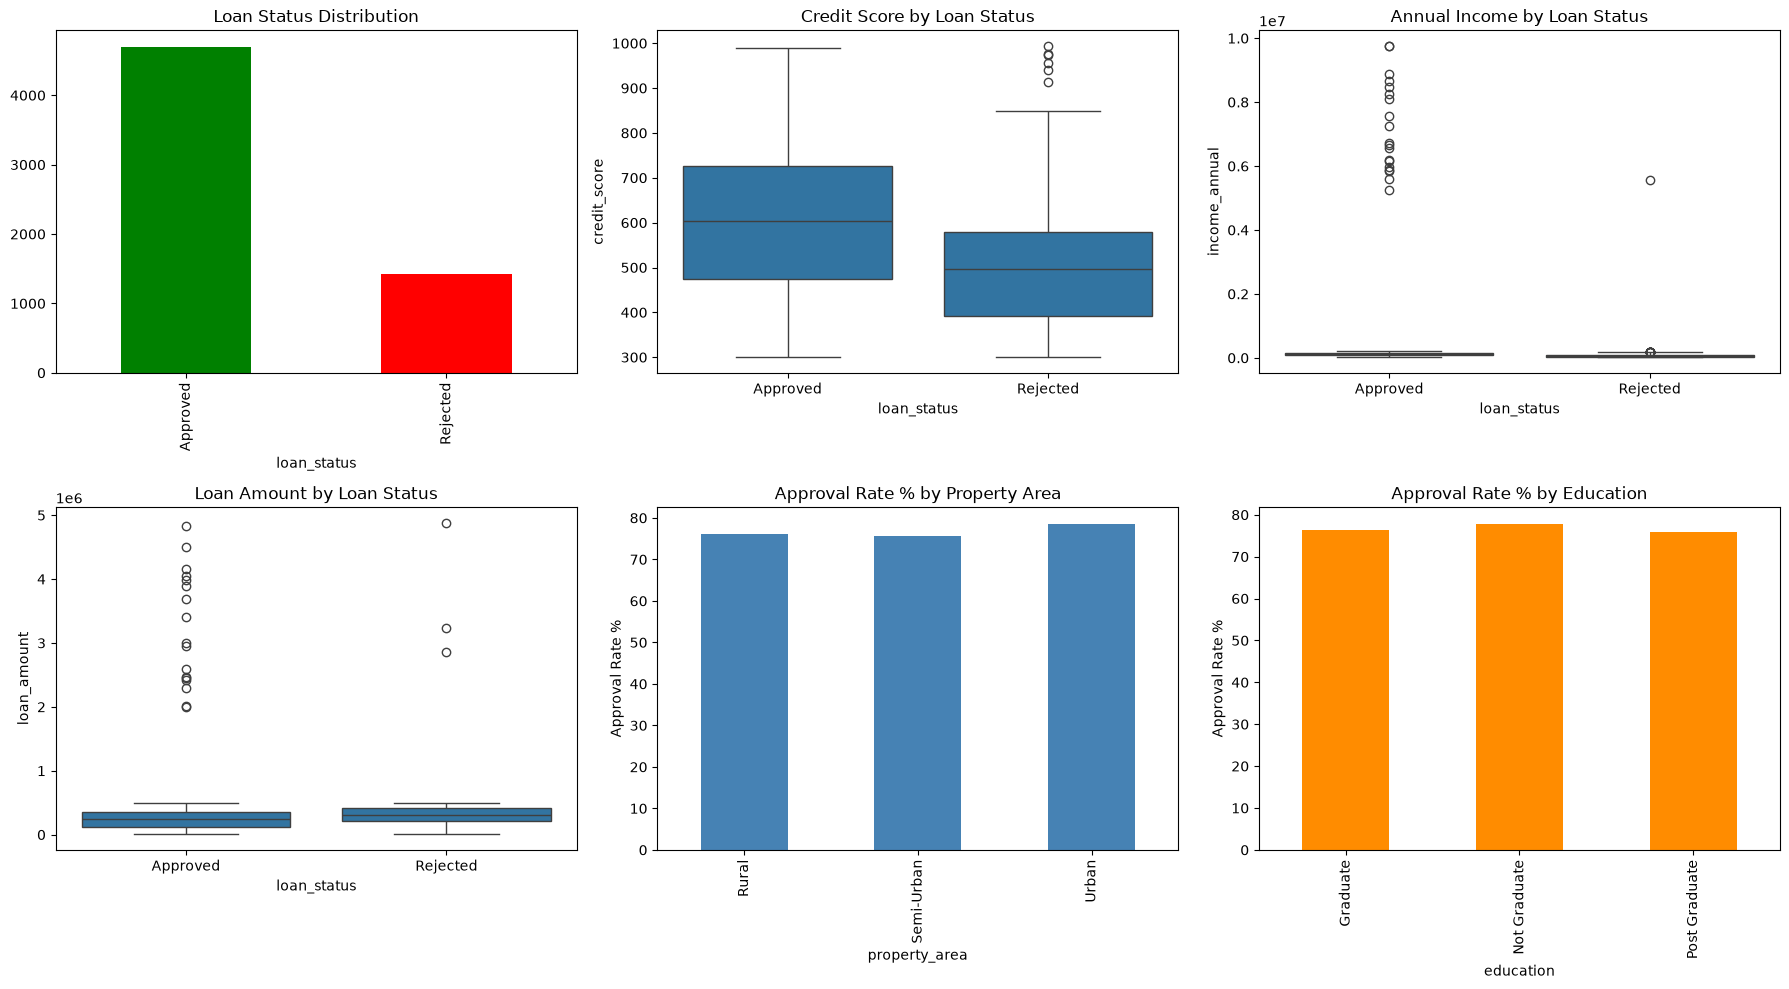

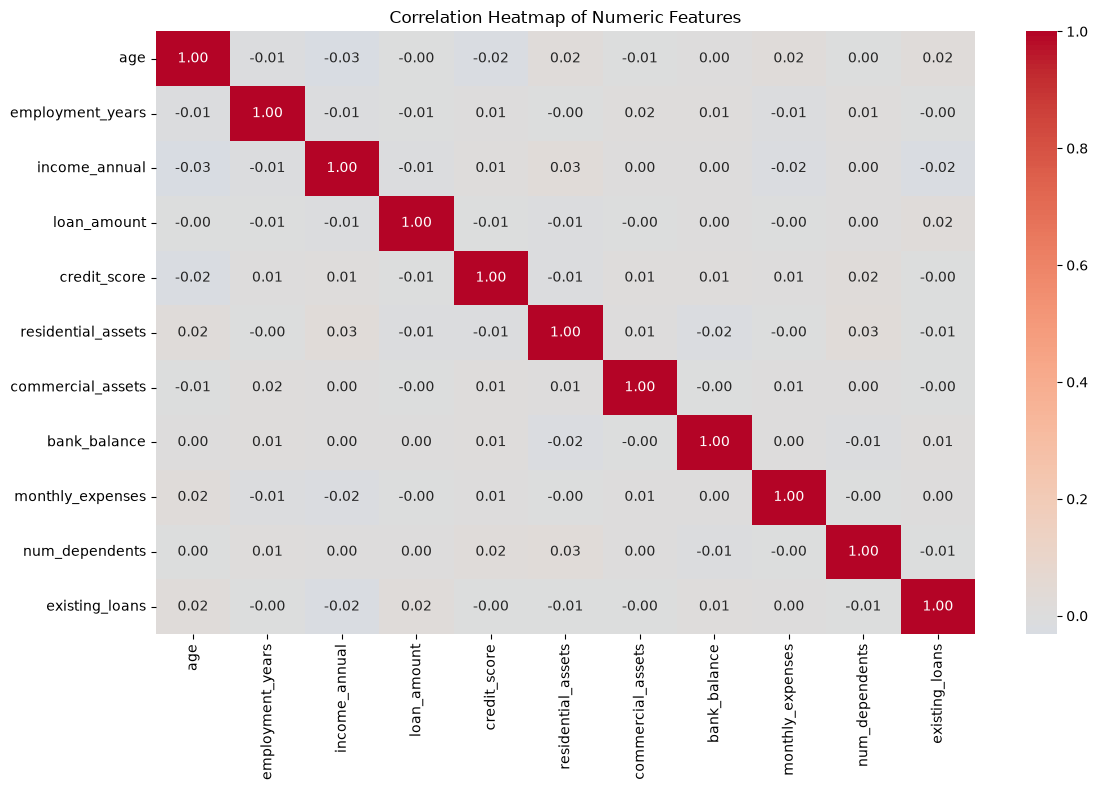


Approval rate by gender:
gender
Female     76.8
Male       77.4
Unknown    74.2
Name: loan_status, dtype: float64

Approval rate by marital_status:
marital_status
Divorced    76.9
Married     76.6
Single      76.6
Unknown     78.3
Name: loan_status, dtype: float64

Approval rate by self_employed:
self_employed
No         76.3
Unknown    75.7
Yes        77.6
Name: loan_status, dtype: float64

Approval rate by property_area:
property_area
Rural         76.2
Semi-Urban    75.6
Urban         78.6
Name: loan_status, dtype: float64

Approval rate by education:
education
Graduate         76.4
Not Graduate     77.9
Post Graduate    75.9
Name: loan_status, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn  as sns

#Target

print("Loan Status Distribution :")
print(df_clean["loan_status"].value_counts())
print(df_clean["loan_status"].value_counts(normalize=True)*100)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df_clean['loan_status'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green','red'])
axes[0,0].set_title('Loan Status Distribution')

sns.boxplot(data=df_clean, x='loan_status', y='credit_score', ax=axes[0,1])
axes[0,1].set_title('Credit Score by Loan Status')

sns.boxplot(data=df_clean, x='loan_status', y='income_annual', ax=axes[0,2])
axes[0,2].set_title('Annual Income by Loan Status')

sns.boxplot(data=df_clean, x='loan_status', y='loan_amount', ax=axes[1,0])
axes[1,0].set_title('Loan Amount by Loan Status')

# 3. Categorical vs approval
approval_by_area = df_clean.groupby('property_area')['loan_status'].apply(
    lambda x: (x == 'Approved').mean() * 100)
approval_by_area.plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Approval Rate % by Property Area')
axes[1,1].set_ylabel('Approval Rate %')

approval_by_edu = df_clean.groupby('education')['loan_status'].apply(
    lambda x: (x == 'Approved').mean() * 100)
approval_by_edu.plot(kind='bar', ax=axes[1,2], color='darkorange')
axes[1,2].set_title('Approval Rate % by Education')
axes[1,2].set_ylabel('Approval Rate %')

plt.tight_layout()

plt.show()

# 4. Correlation heatmap of the numeric features
plt.figure(figsize=(12, 8))
numeric_features = ['age', 'employment_years', 'income_annual', 'loan_amount', 
                     'credit_score', 'residential_assets', 'commercial_assets', 
                     'bank_balance', 'monthly_expenses', 'num_dependents', 'existing_loans']
corr = df_clean[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

# Print approval rates for all the key categoricals
for col in ['gender', 'marital_status', 'self_employed', 'property_area', 'education']:
    print(f"\nApproval rate by {col}:")
    print(df_clean.groupby(col)['loan_status'].apply(lambda x: (x == 'Approved').mean() * 100).round(1))

In [5]:

df_clean['debt_to_income'] = df_clean['loan_amount'] / df_clean['income_annual']

df_clean['total_assets'] = (df_clean['residential_assets'] + 
                              df_clean['commercial_assets'] + 
                              df_clean['bank_balance'])
df_clean['asset_to_loan_ratio'] = df_clean['total_assets'] / df_clean['loan_amount']


df_clean['monthly_income'] = df_clean['income_annual'] / 12
df_clean['expense_ratio'] = df_clean['monthly_expenses'] / df_clean['monthly_income']

# Credit score bands
def credit_band(score):
    if score < 500:
        return 'Poor'
    elif score < 650:
        return 'Fair'
    elif score < 750:
        return 'Good'
    else:
        return 'Excellent'

df_clean['credit_score_band'] = df_clean['credit_score'].apply(credit_band)

# Check the new features
print(df_clean[['debt_to_income', 'total_assets', 'asset_to_loan_ratio', 
                 'expense_ratio', 'credit_score_band']].describe())

print("\nApproval rate by credit_score_band:")
print(df_clean.groupby('credit_score_band')['loan_status'].apply(lambda x: (x=='Approved').mean()*100).round(1))

print("\nAny infinite values (from division)?")
print(df_clean[['debt_to_income', 'asset_to_loan_ratio', 'expense_ratio']].isin([np.inf, -np.inf]).sum())

       debt_to_income  total_assets  asset_to_loan_ratio  expense_ratio
count     6120.000000  6.120000e+03          6120.000000    6120.000000
mean         3.265758  9.019180e+05             8.430615       4.186433
std          3.812507  3.310989e+05            17.171966       3.752904
min          0.006332  3.255700e+04             0.090985       0.007499
25%          1.211922  6.501682e+05             2.260146       1.846874
50%          2.321577  9.038590e+05             3.592573       3.049453
75%          3.948358  1.152880e+06             6.915775       5.062218
max        106.409766  1.750122e+06           227.887637      29.024933

Approval rate by credit_score_band:
credit_score_band
Excellent    91.7
Fair         73.7
Good         90.8
Poor         64.8
Name: loan_status, dtype: float64

Any infinite values (from division)?
debt_to_income         0
asset_to_loan_ratio    0
expense_ratio          0
dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

# Encode target
df_clean['loan_status_encoded'] = df_clean['loan_status'].map({'Approved': 1, 'Rejected': 0})

# Ordinal encode education (order)
education_order = {'Not Graduate': 0, 'Graduate': 1, 'Post Graduate': 2}
df_clean['education_encoded'] = df_clean['education'].map(education_order)

# One-hot encode nominal categoricals
nominal_cols = ['gender', 'marital_status', 'self_employed', 'loan_purpose', 
                 'property_area', 'credit_score_band']
df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

# Drop columns not needed
drop_cols = ['loan_id', 'loan_status', 'education']
df_final = df_encoded.drop(columns=drop_cols)

# Separate features and target
X = df_final.drop(columns=['loan_status_encoded'])
y = df_final['loan_status_encoded']

print("Feature columns:", X.columns.tolist())
print("\nX shape:", X.shape)
print("y shape:", y.shape)

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target balance:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target balance:")
print(y_test.value_counts(normalize=True) * 100)

Feature columns: ['age', 'num_dependents', 'employment_years', 'income_annual', 'loan_amount', 'loan_term_months', 'credit_score', 'existing_loans', 'residential_assets', 'commercial_assets', 'bank_balance', 'monthly_expenses', 'debt_to_income', 'total_assets', 'asset_to_loan_ratio', 'monthly_income', 'expense_ratio', 'education_encoded', 'gender_Male', 'gender_Unknown', 'marital_status_Married', 'marital_status_Single', 'marital_status_Unknown', 'self_employed_Unknown', 'self_employed_Yes', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Personal', 'property_area_Semi-Urban', 'property_area_Urban', 'credit_score_band_Fair', 'credit_score_band_Good', 'credit_score_band_Poor']

X shape: (6120, 34)
y shape: (6120,)

Train shape: (4896, 34)
Test shape: (1224, 34)

Train target balance:
loan_status_encoded
1    76.81781
0    23.18219
Name: proportion, dtype: float64

Test target balance:
loan_status_encoded
1    76.797386
0    23.202614
Name: proportion

In [7]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=8, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# Summary comparison
results_df = pd.DataFrame(results).T
print("\n\nModel Comparison Summary:")
print(results_df.round(4))


Logistic Regression
Accuracy: 0.8342 | Precision: 0.9320 | Recall: 0.8457 | F1: 0.8868

Confusion Matrix:
[[226  58]
 [145 795]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.80      0.69       284
           1       0.93      0.85      0.89       940

    accuracy                           0.83      1224
   macro avg       0.77      0.82      0.79      1224
weighted avg       0.86      0.83      0.84      1224


Decision Tree
Accuracy: 0.9502 | Precision: 0.9721 | Recall: 0.9628 | F1: 0.9674

Confusion Matrix:
[[258  26]
 [ 35 905]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       284
           1       0.97      0.96      0.97       940

    accuracy                           0.95      1224
   macro avg       0.93      0.94      0.93      1224
weighted avg       0.95      0.95      0.95      1224


Random Forest
Accuracy: 0.9510 | Precision:

In [8]:
from sklearn.model_selection import GridSearchCV


# Feature Importance


rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))


# 2. Hyperparameter Tuning
parameters = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=parameters,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)



# Best Model Results

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross Validation F1 Score:")
print(grid_search.best_score_)

#Test Best Model
best_model = grid_search.best_estimator_
prediction = best_model.predict(X_test)
print("\nTest Performance:")
print("Accuracy:",round(accuracy_score(y_test, prediction), 4))
print("Precision:",round(precision_score(y_test, prediction), 4))
print("Recall:", round(recall_score(y_test, prediction), 4))
print("F1 Score:", round(f1_score(y_test, prediction), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))




Top 15 Important Features:
                   Feature  Importance
12          debt_to_income    0.202899
3            income_annual    0.164400
15          monthly_income    0.160307
6             credit_score    0.106706
7           existing_loans    0.071432
16           expense_ratio    0.063084
2         employment_years    0.055356
4              loan_amount    0.034550
33  credit_score_band_Poor    0.022791
14     asset_to_loan_ratio    0.020423
32  credit_score_band_Good    0.013198
11        monthly_expenses    0.012093
9        commercial_assets    0.009435
31  credit_score_band_Fair    0.009356
10            bank_balance    0.009326
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation F1 Score:
0.9759538356733654

Test Performance:
Accuracy: 0.9616
Precision: 0.9745
Recall: 0.9755
F1 Score: 0.975

Confusion Matrix:
[[260  24]
 [ 23 917]]


In [9]:
import joblib
import os

# Create the model directory if it doesn't exist (relative to notebook location)
os.makedirs('../model', exist_ok=True)

# Save the trained Random Forest model
joblib.dump(best_model, '../model/model.pkl')

# Save the exact column structure the model expects (critical for matching input later)
model_columns = X_train.columns.tolist()
joblib.dump(model_columns, '../model/model_columns.pkl')

print("Model saved successfully!")
print(f"Number of features expected: {len(model_columns)}")
print(f"Feature columns: {model_columns}")

Model saved successfully!
Number of features expected: 34
Feature columns: ['age', 'num_dependents', 'employment_years', 'income_annual', 'loan_amount', 'loan_term_months', 'credit_score', 'existing_loans', 'residential_assets', 'commercial_assets', 'bank_balance', 'monthly_expenses', 'debt_to_income', 'total_assets', 'asset_to_loan_ratio', 'monthly_income', 'expense_ratio', 'education_encoded', 'gender_Male', 'gender_Unknown', 'marital_status_Married', 'marital_status_Single', 'marital_status_Unknown', 'self_employed_Unknown', 'self_employed_Yes', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Personal', 'property_area_Semi-Urban', 'property_area_Urban', 'credit_score_band_Fair', 'credit_score_band_Good', 'credit_score_band_Poor']
